In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os
import glob as gb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from zipfile import ZipFile
import cv2

In [2]:
from google.colab import files
files.upload()

Saving kaggle (15).json to kaggle (15).json


{'kaggle (15).json': b'{"username":"neazmulmowla","key":"bc1b2c585fa1ff4db6011cd29095f43a"}'}

In [3]:
!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = [("username", "neazmulmowla"), ("key", "bc1b2c585fa1ff4db6011cd29095f43a")]
api_token_dict = dict(api_token)

import json

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token_dict, file)

!chmod 600 ~/.kaggle/kaggle.json

print('complete')

complete


In [4]:
!kaggle datasets download -d neazmulmowla/15k-per-class-nctcrc

Dataset URL: https://www.kaggle.com/datasets/neazmulmowla/15k-per-class-nctcrc
License(s): unknown
100% 348M/348M [00:19<00:00, 19.0MB/s]



In [5]:
from zipfile import ZipFile
file_name = '/content/15k-per-class-nctcrc.zip'

# IMPORTANT FIX:
# Do not use "as zip" here because that overwrites Python's built-in zip().
with ZipFile(file_name, 'r') as zf:
    zf.extractall('/content')
    print('complete')

complete


In [7]:
DATASET_DIR = "/content/Dataset"

# RAPID-CRC-ADV — Adversarial Label-Poisoning Mitigation

The dataset download and unzip cells above are intentionally preserved from the original notebook.

## Threat model

This version replaces **random symmetric label flipping** with a **model-aware adversarial label-flipping poisoning attack**.

The attack is **offline**: labels are poisoned before the victim/defense model is trained. It is adversarial because a clean surrogate model strategically decides:

1. **which training samples to poison**, and
2. **which wrong class each selected sample should receive**.

For every sample, the attacker compares the clean-label optimization gradient against gradients induced by all incorrect labels. It then chooses a wrong target label that creates a strongly conflicting optimization direction while remaining plausible under the surrogate. The highest-scoring samples are poisoned class-wise until the attack budget reaches 30%.

The RAPID-CRC victim never receives `label_clean`, `is_flipped`, attack targets, or attack scores. Those fields are retained only for attack generation and post-training evaluation.

> **Default attack budget: 30%.**  
> For a 3% attack instead, change only `ATTACK_RATE = 0.30` to `ATTACK_RATE = 0.03`.

In [8]:
# ============================================================
# 0. IMPORTS + REPRODUCIBILITY
# ============================================================
import os
import gc
import math
import copy
import json
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
)

from tqdm.auto import tqdm

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.11.0+cu128
Device : cuda


In [9]:
import re

In [10]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

CLASS_NAMES = ["ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR", "TUM"]
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224

# -------------------- ADVERSARIAL ATTACK --------------------
ATTACK_RATE = 0.30
NOISE_RATE = ATTACK_RATE  # backward-compatible alias

ATTACK_SURROGATE_EPOCHS = 3
ATTACK_HEAD_LR = 3e-4
ATTACK_BACKBONE_LR = 5e-5
ATTACK_WEIGHT_DECAY = 1e-4

# Target score = gradient conflict + target plausibility
ATTACK_GRAD_WEIGHT = 0.75
ATTACK_PLAUS_WEIGHT = 0.25
ATTACK_CLASS_BALANCED = True

# -------------------- VICTIM / DEFENSE ----------------------
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

WARMUP_EPOCHS = 4
ROBUST_EPOCHS = 16
TOTAL_EPOCHS = WARMUP_EPOCHS + ROBUST_EPOCHS

BACKBONE_LR = 3e-5
HEAD_LR = 3e-4
WEIGHT_DECAY = 1e-4

EMA_DECAY = 0.997
LABEL_SMOOTHING = 0.03

RELIABILITY_REFRESH = 2
RELIABILITY_EMA = 0.50
ANCHOR_FRACTION = 0.35

PSEUDO_CONF_THRESHOLD = 0.80
PSEUDO_TEMPERATURE = 0.50
PROTO_TEMPERATURE = 0.12

LAMBDA_CONSISTENCY = 0.50
LAMBDA_PROTO = 0.20

GRAD_PROJ_DIM = 8
GRAD_GMM_REG = 1e-4

USE_PRETRAINED = True

# Strongly recommended: proves mitigation against the same attack.
RUN_UNDEFENDED_CE_BASELINE = True

WORK_DIR = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path("/content")
    if Path("/content").exists()
    else Path.cwd()
)
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("Work directory:", WORK_DIR)
print(f"Adversarial poisoning budget: {ATTACK_RATE:.1%}")

Work directory: /content
Adversarial poisoning budget: 30.0%


## Dataset root

The dataset is already downloaded and extracted by the original-style cells above, so the improved pipeline directly uses `/content/Dataset`.

In [11]:
# ============================================================
# DATASET ROOT FROM ORIGINAL DOWNLOAD CELLS
# ============================================================

from pathlib import Path

DATA_ROOT = Path(DATASET_DIR)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"{DATA_ROOT} was not found. Run the dataset download and extraction cells above first."
    )

missing_classes = [c for c in CLASS_NAMES if not (DATA_ROOT / c).is_dir()]
if missing_classes:
    raise FileNotFoundError(
        "Dataset was extracted, but these class folders are missing: "
        + ", ".join(missing_classes)
    )

print("DATA_ROOT:", DATA_ROOT)

DATA_ROOT: /content/Dataset


In [12]:
# ============================================================
# 3. BUILD DATAFRAME + CLEAN SPLIT
#    NO LABELS ARE POISONED IN THIS CELL
# ============================================================

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

records = []
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

for cls in CLASS_NAMES:
    cls_dir = DATA_ROOT / cls
    paths = sorted([
        p for p in cls_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTS
    ])
    print(f"{cls:>4}: {len(paths):,}")
    for p in paths:
        records.append({
            "filepath": str(p),
            "label_clean": class_to_idx[cls],
            "label_name": cls,
        })

df = pd.DataFrame(records)
if len(df) == 0:
    raise RuntimeError("No images were found under the discovered class folders.")

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_clean"],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_clean"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df["sample_id"] = np.arange(len(train_df), dtype=np.int64)
val_df["sample_id"] = np.arange(len(val_df), dtype=np.int64)
test_df["sample_id"] = np.arange(len(test_df), dtype=np.int64)

# Still clean here. The adversarial cell later overwrites only train_df["label"].
train_df["label"] = train_df["label_clean"].astype(int)
train_df["is_flipped"] = 0
train_df["attack_target"] = -1
train_df["attack_score"] = np.nan
train_df["attack_gradient_conflict"] = np.nan
train_df["attack_target_plausibility"] = np.nan
train_df["attack_surrogate_confidence"] = np.nan

val_df["label"] = val_df["label_clean"].astype(int)
test_df["label"] = test_df["label_clean"].astype(int)

train_df.to_csv(WORK_DIR / "train_clean_before_attack.csv", index=False)
val_df.to_csv(WORK_DIR / "val_clean.csv", index=False)
test_df.to_csv(WORK_DIR / "test_clean.csv", index=False)

print(f"\nTotal: {len(df):,}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print("Training labels are currently clean.")
print("Adversarial poisoning will be created after the model definition.")

assert train_df["sample_id"].is_unique
assert set(train_df["label"].unique()).issubset(set(range(NUM_CLASSES)))

 ADI: 1,500
BACK: 1,500
 DEB: 1,500
 LYM: 1,500
 MUC: 1,500
 MUS: 1,500
NORM: 1,500
 STR: 1,500
 TUM: 1,500

Total: 13,500
Train: 9,450 | Val: 2,025 | Test: 2,025
Training labels are currently clean.
Adversarial poisoning will be created after the model definition.


In [13]:
# ============================================================
# 4. AUGMENTATIONS + DATASETS + REBUILDABLE LOADERS
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

weak_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

strong_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(20),
    T.RandomApply([
        T.ColorJitter(
            brightness=0.20,
            contrast=0.20,
            saturation=0.18,
            hue=0.03,
        )
    ], p=0.80),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))], p=0.15),
    T.ToTensor(),
    T.RandomErasing(
        p=0.15,
        scale=(0.02, 0.10),
        ratio=(0.5, 2.0),
        value="random",
    ),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CRCTrainDataset(Dataset):
    """Victim/defense dataset. It returns only the observed label."""

    def __init__(self, frame):
        self.df = frame.reset_index(drop=True).copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        return {
            "weak": weak_transform(image),
            "strong": strong_transform(image),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "index": torch.tensor(int(row["sample_id"]), dtype=torch.long),
            "path": row["filepath"],
        }

class CRCEvalDataset(Dataset):
    def __init__(self, frame):
        self.df = frame.reset_index(drop=True).copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        return {
            "image": eval_transform(image),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "index": torch.tensor(int(row["sample_id"]), dtype=torch.long),
            "path": row["filepath"],
        }

class CRCAttackDataset(Dataset):
    """Attacker-only dataset using clean labels before poisoning."""

    def __init__(self, frame, transform):
        self.df = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        return {
            "image": self.transform(image),
            "label_clean": torch.tensor(int(row["label_clean"]), dtype=torch.long),
            "index": torch.tensor(int(row["sample_id"]), dtype=torch.long),
        }

persistent = NUM_WORKERS > 0

def build_main_loaders():
    """Rebuild victim loaders from the CURRENT train_df labels."""
    global train_dataset, analysis_dataset, val_dataset, test_dataset
    global train_loader, analysis_loader, val_loader, test_loader

    train_dataset = CRCTrainDataset(train_df)
    analysis_dataset = CRCTrainDataset(train_df)
    val_dataset = CRCEvalDataset(val_df)
    test_dataset = CRCEvalDataset(test_df)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=AMP_ENABLED,
        persistent_workers=persistent,
        drop_last=False,
    )
    analysis_loader = DataLoader(
        analysis_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=AMP_ENABLED,
        persistent_workers=persistent,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=AMP_ENABLED,
        persistent_workers=persistent,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=AMP_ENABLED,
        persistent_workers=persistent,
    )

# Initial clean loaders.
build_main_loaders()

# Attacker loaders make their own clean-label copies now.
attack_train_dataset = CRCAttackDataset(train_df, strong_transform)
attack_score_dataset = CRCAttackDataset(train_df, eval_transform)

attack_train_loader = DataLoader(
    attack_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=AMP_ENABLED,
    persistent_workers=persistent,
    drop_last=False,
)
attack_score_loader = DataLoader(
    attack_score_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=AMP_ENABLED,
    persistent_workers=persistent,
    drop_last=False,
)

batch = next(iter(train_loader))
print("Weak  :", tuple(batch["weak"].shape))
print("Strong:", tuple(batch["strong"].shape))
print("Labels:", tuple(batch["label"].shape))
print("IDs   :", tuple(batch["index"].shape))

Weak  : (32, 3, 224, 224)
Strong: (32, 3, 224, 224)
Labels: (32,)
IDs   : (32,)


## 5. Model: ConvNeXt-Tiny + Dual-Pool Gate

The original notebook trained a custom sequential state-space block from scratch. On a visual histopathology task, that creates a large optimization burden and throws away strong transfer-learning priors.

This version uses:
1. **ImageNet-pretrained ConvNeXt-Tiny** features when weights are available.
2. **Learned average/max dual pooling** to retain both global tissue composition and highly discriminative local responses.
3. A normalized 256-D embedding used by both the classifier and prototype/gradient reliability modules.

In [14]:
# ============================================================
# 5. MODEL
# ============================================================

class GatedDualPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        hidden = max(64, dim // 4)
        self.gate = nn.Sequential(
            nn.Linear(dim * 2, hidden),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(hidden, dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        avg = F.adaptive_avg_pool2d(x, 1).flatten(1)
        mx  = F.adaptive_max_pool2d(x, 1).flatten(1)
        g = self.gate(torch.cat([avg, mx], dim=1))
        return g * avg + (1.0 - g) * mx

class RapidCRCNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, emb_dim=256, pretrained=USE_PRETRAINED):
        super().__init__()

        weights = ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
        try:
            base = convnext_tiny(weights=weights)
            self.pretrained_loaded = weights is not None
        except Exception as e:
            warnings.warn(
                f"Pretrained weights could not be loaded ({type(e).__name__}: {e}). "
                "Falling back to random initialization. For best results on Kaggle, enable Internet "
                "or make the torchvision weights available."
            )
            base = convnext_tiny(weights=None)
            self.pretrained_loaded = False

        feat_dim = base.classifier[2].in_features
        self.backbone = base.features
        self.pool = GatedDualPool(feat_dim)
        self.projector = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, emb_dim),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(emb_dim, emb_dim),
        )
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        fmap = self.backbone(x)
        pooled = self.pool(fmap)
        emb_raw = self.projector(pooled)
        emb = F.normalize(emb_raw, dim=1)
        logits = self.classifier(emb)
        return {
            "logits": logits,
            "embedding": emb,
            "pooled": pooled,
        }

smoke_model = RapidCRCNet().to(DEVICE)

with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out = smoke_model(dummy)

print("Logits   :", tuple(out["logits"].shape))
print("Embedding:", tuple(out["embedding"].shape))
print("Parameters:", f"{sum(p.numel() for p in smoke_model.parameters()):,}")
print("Pretrained weights loaded:", smoke_model.pretrained_loaded)
del dummy, out, smoke_model
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 168MB/s]


Logits   : (2, 9)
Embedding: (2, 256)
Parameters: 28,528,425
Pretrained weights loaded: True


## 6. White-box gradient-guided adversarial label-flipping attack

The attack is generated **before victim training**.

### Clean surrogate
A short surrogate model with the same RAPID-CRC backbone is trained on the clean pre-attack training labels. It represents attacker knowledge and is discarded before the defense is trained.

For a sample with clean label \(y_i\), surrogate probability \(p_i\), and classifier matrix \(W\), the embedding gradient induced by assigning candidate label \(k\) is

\[
g_i^{(k)} = W^\top(p_i-e_k).
\]

The clean-label gradient is \(g_i^{(y_i)}\). For each wrong class \(k\neq y_i\), the attack computes a gradient-conflict score

\[
a_{ik}=\frac{1-\cos(g_i^{(y_i)},g_i^{(k)})}{2}.
\]

A plausibility term based on the surrogate's probability for class \(k\) is added so the attack does not always choose obviously implausible labels:

\[
s_{ik}
=
\alpha a_{ik}
+
(1-\alpha)\tilde p_{ik},
\qquad \alpha=0.75.
\]

The malicious target is

\[
y_i^{adv}
=
\arg\max_{k\neq y_i}s_{ik}.
\]

Samples are ranked within each clean class using the target score, surrogate confidence, and malicious gradient magnitude. The top 30% are flipped. Thus the poisoning budget is controlled and class-balanced.

In [15]:
# ============================================================
# 6. GENERATE THE ADVERSARIAL LABEL-POISONING ATTACK
# ============================================================

from contextlib import nullcontext

def attack_autocast():
    if DEVICE.type == "cuda":
        try:
            return torch.amp.autocast("cuda", enabled=True)
        except Exception:
            return torch.cuda.amp.autocast(enabled=True)
    return nullcontext()

def attack_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

def configure_surrogate_trainable_layers(model):
    """
    Train the projection/classification head plus the final ConvNeXt stage.
    This provides a useful model-aware surrogate while keeping attack
    generation computationally manageable.
    """
    for p in model.backbone.parameters():
        p.requires_grad_(False)

    children = list(model.backbone.children())
    for block in children[-2:]:
        for p in block.parameters():
            p.requires_grad_(True)

    for p in model.pool.parameters():
        p.requires_grad_(True)
    for p in model.projector.parameters():
        p.requires_grad_(True)
    for p in model.classifier.parameters():
        p.requires_grad_(True)

def make_attack_optimizer(model):
    backbone_params = []
    head_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("backbone."):
            backbone_params.append(p)
        else:
            head_params.append(p)

    return torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": ATTACK_BACKBONE_LR},
            {"params": head_params, "lr": ATTACK_HEAD_LR},
        ],
        weight_decay=ATTACK_WEIGHT_DECAY,
    )

def train_attack_surrogate(model, loader, epochs=ATTACK_SURROGATE_EPOCHS):
    model.train()
    optimizer = make_attack_optimizer(model)
    scaler = attack_scaler()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(
            loader,
            desc=f"Attack surrogate {epoch+1}/{epochs}",
            leave=False,
        )

        for batch in pbar:
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["label_clean"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with attack_autocast():
                logits = model(x)["logits"]
                loss = F.cross_entropy(logits, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                1.0,
            )
            scaler.step(optimizer)
            scaler.update()

            bs = y.size(0)
            running_loss += float(loss.item()) * bs
            correct += (logits.argmax(1) == y).sum().item()
            total += bs

            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{correct/max(1,total):.4f}",
            )

        print(
            f"Surrogate epoch {epoch+1}: "
            f"loss={running_loss/max(1,total):.4f}, "
            f"clean-train acc={correct/max(1,total):.4f}"
        )

@torch.no_grad()
def score_adversarial_targets(model, loader):
    """
    Computes a model-aware wrong target for every clean training sample.

    No per-sample backward loop is required because the embedding gradient
    of cross-entropy is available analytically.
    """
    model.eval()

    n = len(loader.dataset)
    attack_target = np.full(n, -1, dtype=np.int64)
    attack_score = np.zeros(n, dtype=np.float32)
    grad_conflict = np.zeros(n, dtype=np.float32)
    target_plaus = np.zeros(n, dtype=np.float32)
    clean_conf = np.zeros(n, dtype=np.float32)
    malicious_grad_norm = np.zeros(n, dtype=np.float32)

    W = model.classifier.weight.detach().float()  # [C, D]

    for batch in tqdm(loader, desc="Adversarial target scoring", leave=False):
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["label_clean"].to(DEVICE, non_blocking=True)
        idx = batch["index"].cpu().numpy()

        with attack_autocast():
            out = model(x)

        logits = out["logits"].float()
        probs = torch.softmax(logits, dim=1)

        onehot_y = F.one_hot(y, NUM_CLASSES).float()
        g_clean = (probs - onehot_y) @ W

        # g_i^(k) = pW - W_k for all candidate labels k.
        pW = probs @ W
        g_all = pW[:, None, :] - W[None, :, :]

        cos = F.cosine_similarity(
            g_clean[:, None, :],
            g_all,
            dim=2,
            eps=1e-8,
        )
        anti = 0.5 * (1.0 - cos)

        # Plausibility among incorrect classes.
        wrong_probs = probs.clone()
        row = torch.arange(len(y), device=DEVICE)
        wrong_probs[row, y] = 0.0
        max_wrong = wrong_probs.max(dim=1, keepdim=True).values.clamp_min(1e-8)
        plaus = wrong_probs / max_wrong

        candidate_score = (
            ATTACK_GRAD_WEIGHT * anti
            + ATTACK_PLAUS_WEIGHT * plaus
        )
        candidate_score[row, y] = -1e9

        target = candidate_score.argmax(dim=1)

        chosen_base = candidate_score[row, target]
        chosen_conflict = anti[row, target]
        chosen_plaus = plaus[row, target]
        chosen_grad = g_all[row, target]
        chosen_grad_norm = chosen_grad.norm(dim=1)
        y_conf = probs[row, y]

        # High conflict + high clean confidence + a strong malicious gradient.
        final_score = (
            chosen_base
            * (0.50 + 0.50 * y_conf)
            * torch.log1p(chosen_grad_norm)
        )

        attack_target[idx] = target.cpu().numpy()
        attack_score[idx] = final_score.cpu().numpy()
        grad_conflict[idx] = chosen_conflict.cpu().numpy()
        target_plaus[idx] = chosen_plaus.cpu().numpy()
        clean_conf[idx] = y_conf.cpu().numpy()
        malicious_grad_norm[idx] = chosen_grad_norm.cpu().numpy()

    return {
        "target": attack_target,
        "score": attack_score,
        "gradient_conflict": grad_conflict,
        "target_plausibility": target_plaus,
        "clean_confidence": clean_conf,
        "malicious_grad_norm": malicious_grad_norm,
    }

def apply_adversarial_attack(frame, attack_info, attack_rate=ATTACK_RATE):
    """
    Select top-scoring samples within each clean class and flip them to
    their model-aware adversarial target labels.
    """
    attacked = frame.copy().reset_index(drop=True)

    # Safe to rerun.
    attacked["label"] = attacked["label_clean"].astype(int)
    attacked["is_flipped"] = 0
    attacked["attack_target"] = attack_info["target"]
    attacked["attack_score"] = attack_info["score"]
    attacked["attack_gradient_conflict"] = attack_info["gradient_conflict"]
    attacked["attack_target_plausibility"] = attack_info["target_plausibility"]
    attacked["attack_surrogate_confidence"] = attack_info["clean_confidence"]
    attacked["attack_malicious_grad_norm"] = attack_info["malicious_grad_norm"]

    selected = []

    if ATTACK_CLASS_BALANCED:
        clean_np = attacked["label_clean"].to_numpy(dtype=np.int64)

        for cls in range(NUM_CLASSES):
            idx = np.where(clean_np == cls)[0]
            n_poison = int(round(attack_rate * len(idx)))

            if n_poison == 0:
                continue

            ranked = idx[np.argsort(attack_info["score"][idx])[::-1]]
            selected.extend(ranked[:n_poison].tolist())
    else:
        n_poison = int(round(attack_rate * len(attacked)))
        ranked = np.argsort(attack_info["score"])[::-1]
        selected = ranked[:n_poison].tolist()

    selected = np.asarray(sorted(set(selected)), dtype=np.int64)

    clean = attacked["label_clean"].to_numpy(dtype=np.int64)
    target = attacked["attack_target"].to_numpy(dtype=np.int64)

    if len(selected) > 0 and np.any(target[selected] == clean[selected]):
        raise RuntimeError("Adversarial target unexpectedly equals the clean label.")

    attacked.loc[selected, "label"] = target[selected]
    attacked.loc[selected, "is_flipped"] = 1

    return attacked, selected

# ------------------------------------------------------------
# A. Train attacker surrogate on CLEAN pre-attack labels.
# ------------------------------------------------------------
seed_everything(SEED)

attack_surrogate = RapidCRCNet().to(DEVICE)
configure_surrogate_trainable_layers(attack_surrogate)

print("Training clean surrogate for adversarial attack generation...")
train_attack_surrogate(
    attack_surrogate,
    attack_train_loader,
    epochs=ATTACK_SURROGATE_EPOCHS,
)

# ------------------------------------------------------------
# B. Strategically choose target labels.
# ------------------------------------------------------------
attack_info = score_adversarial_targets(
    attack_surrogate,
    attack_score_loader,
)

# ------------------------------------------------------------
# C. Poison the requested percentage of the training set.
# ------------------------------------------------------------
train_df, adversarial_indices = apply_adversarial_attack(
    train_df,
    attack_info,
    attack_rate=ATTACK_RATE,
)

actual_attack_rate = float(train_df["is_flipped"].mean())
num_poisoned = int(train_df["is_flipped"].sum())

print("\n" + "=" * 72)
print("ADVERSARIAL LABEL-POISONING ATTACK CREATED")
print("=" * 72)
print(f"Requested attack rate : {ATTACK_RATE:.3f}")
print(f"Actual attack rate    : {actual_attack_rate:.3f}")
print(f"Poisoned samples      : {num_poisoned:,} / {len(train_df):,}")
print("Attack type           : offline white-box gradient-guided label flipping")
print("Selection             : class-balanced top-scoring samples")
print("Validation/test       : untouched and clean")

# Clean-label -> adversarial-target transition matrix.
transition = pd.crosstab(
    train_df.loc[train_df["is_flipped"] == 1, "label_clean"],
    train_df.loc[train_df["is_flipped"] == 1, "label"],
    rownames=["clean_class"],
    colnames=["adversarial_target"],
    dropna=False,
)
transition = transition.reindex(
    index=range(NUM_CLASSES),
    columns=range(NUM_CLASSES),
    fill_value=0,
)
transition.index = [CLASS_NAMES[i] for i in transition.index]
transition.columns = [CLASS_NAMES[i] for i in transition.columns]

print("\nAdversarial label transition matrix:")
display(transition)

attack_csv = WORK_DIR / f"train_adversarial_poison_{int(round(ATTACK_RATE*100))}.csv"
train_df.to_csv(attack_csv, index=False)
transition.to_csv(WORK_DIR / "adversarial_transition_matrix.csv")

print("\nSaved attacked training set:", attack_csv)

# ------------------------------------------------------------
# D. Rebuild victim loaders AFTER poisoning.
# ------------------------------------------------------------
build_main_loaders()

poisoned_batch = next(iter(train_loader))
print("\nVictim loader rebuilt after attack.")
print("Victim batch labels shape:", tuple(poisoned_batch["label"].shape))

# The attacker model is discarded. It never participates in defense training.
del attack_surrogate
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Training clean surrogate for adversarial attack generation...


Attack surrogate 1/3:   0%|          | 0/296 [00:00<?, ?it/s]

Surrogate epoch 1: loss=1.4881, clean-train acc=0.8539


Attack surrogate 2/3:   0%|          | 0/296 [00:00<?, ?it/s]

Surrogate epoch 2: loss=0.8683, clean-train acc=0.9465


...

Surrogate epoch 3: loss=0.5713, clean-train acc=0.9541


Adversarial target scoring:   0%|          | 0/296 [00:00<?, ?it/s]


ADVERSARIAL LABEL-POISONING ATTACK CREATED
Requested attack rate : 0.300
Actual attack rate    : 0.300
Poisoned samples      : 2,835 / 9,450
Attack type           : offline white-box gradient-guided label flipping
Selection             : class-balanced top-scoring samples
Validation/test       : untouched and clean

Adversarial label transition matrix:


,ADI,BACK,DEB,LYM,MUC,MUS,NORM,STR,TUM
ADI,0,0,0,251,0,63,1,0,0
BACK,268,0,38,0,0,8,1,0,0
DEB,1,0,0,160,25,37,6,21,65
LYM,7,0,21,0,234,18,13,0,22
MUC,99,4,8,83,0,5,107,0,9
MUS,40,0,5,1,13,0,3,239,14
NORM,2,0,0,5,288,16,0,4,0
STR,3,0,90,0,11,188,7,0,16
TUM,2,1,5,1,5,27,267,7,0



Saved attacked training set: /content/train_adversarial_poison_30.csv

Victim loader rebuilt after attack.
Victim batch labels shape: (32,)


In [16]:
# ============================================================
# 6. EMA TEACHER + OPTIMIZER HELPERS
# ============================================================

class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.decay = decay
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        ema_state = self.ema.state_dict()
        model_state = model.state_dict()
        for k, v_ema in ema_state.items():
            v_model = model_state[k].detach()
            if torch.is_floating_point(v_ema):
                v_ema.mul_(self.decay).add_(v_model, alpha=1.0 - self.decay)
            else:
                v_ema.copy_(v_model)

def make_optimizer(model):
    backbone_params = []
    head_params = []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("backbone."):
            backbone_params.append(p)
        else:
            head_params.append(p)

    return torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )

def make_scaler():
    # Compatible with both older and newer PyTorch.
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

def amp_context():
    try:
        return torch.amp.autocast("cuda", enabled=AMP_ENABLED)
    except Exception:
        return torch.cuda.amp.autocast(enabled=AMP_ENABLED)

@torch.no_grad()
def sharpen_probs(p, temperature=PSEUDO_TEMPERATURE):
    if abs(temperature - 1.0) < 1e-8:
        return p
    q = p.clamp_min(1e-7).pow(1.0 / temperature)
    return q / q.sum(dim=1, keepdim=True)

In [17]:
# ============================================================
# 7. METRICS / EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    total_loss = 0.0
    total_n = 0

    for batch in loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        with amp_context():
            logits = model(images)["logits"]
            loss = F.cross_entropy(logits, labels, reduction="sum")

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        total_loss += float(loss.item())
        total_n += labels.numel()

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    y = np.concatenate(all_labels)
    pred = np.concatenate(all_preds)
    prob = np.concatenate(all_probs)

    return {
        "loss": total_loss / max(1, total_n),
        "accuracy": accuracy_score(y, pred),
        "precision_macro": precision_score(y, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y, pred, average="macro", zero_division=0),
        "labels": y,
        "preds": pred,
        "probs": prob,
    }

In [18]:
# ============================================================
# 8. WARM-UP TRAINING
# ============================================================

def train_warmup_epoch(model, ema, loader, optimizer, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)
    for batch in pbar:
        images = batch["strong"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with amp_context():
            logits = model(images)["logits"]
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=LABEL_SMOOTHING,
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/max(1,total):.4f}")

    return {
        "loss": running_loss / max(1, total),
        "accuracy": correct / max(1, total),
    }

## Reliability estimation for adversarially poisoned supervision

After the adversarial attack is fixed, RAPID-CRC trains only with the **observed (possibly poisoned) labels**. It does not know which samples were attacked.

Each training image receives four complementary reliability signals:

1. **Class-wise small-loss reliability** — samples inconsistent with their observed labels often exhibit larger observed-label loss.
2. **EMA teacher–student consistency** — trustworthy samples should remain semantically stable across weak and strong augmentations.
3. **Prototype margin** — an image should be closer to the prototype of its observed class than to competing class prototypes.
4. **Class-conditioned gradient-signature clustering** — the analytical embedding gradient
   \[
   g_i=W^\top(p_i-y_i)
   \]
   is projected and clustered within each observed class using a two-component GMM.

The four signals are fused into a continuous reliability probability. Low-reliability samples are not simply removed; they can be softly corrected using confident EMA-teacher predictions.

In [19]:
# ============================================================
# 9A. RELIABILITY UTILITIES
# ============================================================

def robust_sigmoid_score(values, higher_is_clean=True):
    values = np.asarray(values, dtype=np.float64)
    med = np.median(values)
    mad = np.median(np.abs(values - med))
    scale = 1.4826 * mad + 1e-6
    z = (values - med) / scale
    if not higher_is_clean:
        z = -z
    z = np.clip(z, -8.0, 8.0)
    return 1.0 / (1.0 + np.exp(-z))

def classwise_robust_score(values, labels, higher_is_clean=True):
    out = np.zeros(len(values), dtype=np.float32)
    for cls in range(NUM_CLASSES):
        idx = np.where(labels == cls)[0]
        if len(idx) == 0:
            continue
        out[idx] = robust_sigmoid_score(values[idx], higher_is_clean).astype(np.float32)
    return out

def js_consistency(p, q):
    # p, q: numpy arrays [N, C]
    eps = 1e-8
    p = np.clip(p, eps, 1.0)
    q = np.clip(q, eps, 1.0)
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * (np.log(p) - np.log(m)), axis=1)
    kl_qm = np.sum(q * (np.log(q) - np.log(m)), axis=1)
    js = 0.5 * (kl_pm + kl_qm) / np.log(2.0)
    return np.clip(1.0 - js, 0.0, 1.0).astype(np.float32)

@torch.no_grad()
def collect_reliability_inputs(student, teacher, loader):
    student.eval()
    teacher.eval()

    n = len(loader.dataset)
    emb_dim = student.classifier.in_features

    labels = np.zeros(n, dtype=np.int64)
    pt_all = np.zeros((n, NUM_CLASSES), dtype=np.float32)
    ps_all = np.zeros((n, NUM_CLASSES), dtype=np.float32)
    emb_all = np.zeros((n, emb_dim), dtype=np.float32)

    for batch in tqdm(loader, desc="Reliability pass", leave=False):
        xw = batch["weak"].to(DEVICE, non_blocking=True)
        xs = batch["strong"].to(DEVICE, non_blocking=True)
        y = batch["label"].cpu().numpy()
        idx = batch["index"].cpu().numpy()

        with amp_context():
            out_t = teacher(xw)
            out_s = student(xs)

        pt = torch.softmax(out_t["logits"].float(), dim=1)
        ps = torch.softmax(out_s["logits"].float(), dim=1)
        emb = F.normalize(out_t["embedding"].float(), dim=1)

        labels[idx] = y
        pt_all[idx] = pt.cpu().numpy()
        ps_all[idx] = ps.cpu().numpy()
        emb_all[idx] = emb.cpu().numpy()

    return labels, pt_all, ps_all, emb_all

In [20]:
# ============================================================
# 9B. PROTOTYPES + GRADIENT CLUSTERING
# ============================================================

def build_prototypes(embeddings, labels, base_clean_score, anchor_fraction=ANCHOR_FRACTION):
    emb = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    prototypes = np.zeros((NUM_CLASSES, emb.shape[1]), dtype=np.float32)

    for cls in range(NUM_CLASSES):
        idx = np.where(labels == cls)[0]
        if len(idx) == 0:
            continue

        k = max(16, int(round(anchor_fraction * len(idx))))
        k = min(k, len(idx))
        chosen = idx[np.argsort(base_clean_score[idx])[-k:]]

        proto = emb[chosen].mean(axis=0)
        proto = proto / (np.linalg.norm(proto) + 1e-8)
        prototypes[cls] = proto.astype(np.float32)

    return prototypes

def prototype_margin_score(embeddings, labels, prototypes):
    emb = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    prot = prototypes / (np.linalg.norm(prototypes, axis=1, keepdims=True) + 1e-8)
    sims = emb @ prot.T

    own = sims[np.arange(len(labels)), labels]
    tmp = sims.copy()
    tmp[np.arange(len(labels)), labels] = -np.inf
    alt = np.max(tmp, axis=1)
    margin = own - alt

    clean_score = classwise_robust_score(margin, labels, higher_is_clean=True)
    return margin.astype(np.float32), clean_score

def gradient_cluster_clean_probability(
    teacher_probs,
    labels,
    classifier_weight,
    observed_ce,
    proj_dim=GRAD_PROJ_DIM,
):
    # dL/dz = (p - y_onehot) @ W
    onehot = np.eye(NUM_CLASSES, dtype=np.float32)[labels]
    residual = teacher_probs.astype(np.float32) - onehot
    grad = residual @ classifier_weight.astype(np.float32)

    rng = np.random.default_rng(SEED)
    R = rng.normal(size=(grad.shape[1], proj_dim)).astype(np.float32)
    R /= np.linalg.norm(R, axis=0, keepdims=True) + 1e-8

    projected = grad @ R
    grad_norm = np.log1p(np.linalg.norm(grad, axis=1, keepdims=True))
    signatures = np.concatenate([projected, grad_norm], axis=1)

    clean_prob = np.zeros(len(labels), dtype=np.float32)

    for cls in range(NUM_CLASSES):
        idx = np.where(labels == cls)[0]
        if len(idx) < 20:
            clean_prob[idx] = robust_sigmoid_score(observed_ce[idx], higher_is_clean=False)
            continue

        X = signatures[idx]
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)

        try:
            gmm = GaussianMixture(
                n_components=2,
                covariance_type="diag",
                reg_covar=GRAD_GMM_REG,
                n_init=3,
                random_state=SEED,
            )
            gmm.fit(Xs)
            post = gmm.predict_proba(Xs)
            comp = gmm.predict(Xs)

            mean_loss = []
            for k in range(2):
                mask = comp == k
                mean_loss.append(np.mean(observed_ce[idx][mask]) if mask.any() else np.inf)

            clean_component = int(np.argmin(mean_loss))
            clean_prob[idx] = post[:, clean_component].astype(np.float32)

        except Exception as e:
            warnings.warn(f"Gradient GMM failed for class {cls}: {e}. Falling back to loss score.")
            clean_prob[idx] = robust_sigmoid_score(observed_ce[idx], higher_is_clean=False)

    return np.clip(clean_prob, 0.0, 1.0)

In [21]:
# ============================================================
# 9C. FULL RELIABILITY ESTIMATOR
# ============================================================

@dataclass
class MethodFlags:
    use_loss: bool = True
    use_consistency: bool = True
    use_prototype: bool = True
    use_gradient_cluster: bool = True
    use_pseudo_correction: bool = True
    use_prototype_loss: bool = True

FULL_METHOD = MethodFlags()

@torch.no_grad()
def estimate_reliability(student, teacher, loader, flags=FULL_METHOD, previous=None):
    labels, pt, ps, emb = collect_reliability_inputs(student, teacher, loader)

    obs_prob = np.clip(pt[np.arange(len(labels)), labels], 1e-8, 1.0)
    observed_ce = -np.log(obs_prob)
    teacher_conf = pt.max(axis=1)

    loss_clean = classwise_robust_score(observed_ce, labels, higher_is_clean=False)

    consistency_clean = js_consistency(pt, ps)

    # Base anchors use only loss + teacher confidence.
    conf_clean = classwise_robust_score(teacher_conf, labels, higher_is_clean=True)
    base_clean = 0.65 * loss_clean + 0.35 * conf_clean

    prototypes = build_prototypes(emb, labels, base_clean)
    proto_margin, proto_clean = prototype_margin_score(emb, labels, prototypes)

    W = teacher.classifier.weight.detach().float().cpu().numpy()
    grad_clean = gradient_cluster_clean_probability(
        pt, labels, W, observed_ce, proj_dim=GRAD_PROJ_DIM
    )

    signals = []
    weights = []

    if flags.use_loss:
        signals.append(loss_clean); weights.append(0.35)
    if flags.use_prototype:
        signals.append(proto_clean); weights.append(0.25)
    if flags.use_consistency:
        signals.append(consistency_clean); weights.append(0.20)
    if flags.use_gradient_cluster:
        signals.append(grad_clean); weights.append(0.20)

    if not signals:
        reliability = np.ones(len(labels), dtype=np.float32)
    else:
        w = np.asarray(weights, dtype=np.float32)
        w = w / w.sum()
        reliability = sum(float(wi) * s for wi, s in zip(w, signals)).astype(np.float32)

    reliability = np.clip(reliability, 0.05, 0.99)

    if previous is not None:
        reliability = (
            RELIABILITY_EMA * previous.astype(np.float32)
            + (1.0 - RELIABILITY_EMA) * reliability
        )
        reliability = np.clip(reliability, 0.05, 0.99)

    info = {
        "reliability": reliability,
        "loss_clean": loss_clean,
        "consistency_clean": consistency_clean,
        "proto_clean": proto_clean,
        "grad_clean": grad_clean,
        "proto_margin": proto_margin,
        "teacher_conf": teacher_conf.astype(np.float32),
        "teacher_probs": pt,
        "prototypes": prototypes.astype(np.float32),
        "labels": labels,
    }
    return info

In [22]:
# ============================================================
# 10. RELIABILITY-ADAPTIVE ROBUST TRAINING
# ============================================================

def soft_cross_entropy(logits, targets):
    return -(targets * F.log_softmax(logits, dim=1)).sum(dim=1)

def train_robust_epoch(
    model,
    ema,
    loader,
    optimizer,
    scaler,
    reliability_info,
    flags=FULL_METHOD,
):
    model.train()
    teacher = ema.ema
    teacher.eval()

    reliability_np = reliability_info["reliability"]
    prototypes = torch.tensor(
        reliability_info["prototypes"],
        dtype=torch.float32,
        device=DEVICE,
    )
    prototypes = F.normalize(prototypes, dim=1)

    running = {"loss": 0.0, "cls": 0.0, "cons": 0.0, "proto": 0.0}
    correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)
    for batch in pbar:
        xw = batch["weak"].to(DEVICE, non_blocking=True)
        xs = batch["strong"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        idx_np = batch["index"].cpu().numpy()

        r = torch.tensor(
            reliability_np[idx_np],
            dtype=torch.float32,
            device=DEVICE,
        )

        with torch.no_grad():
            with amp_context():
                out_t = teacher(xw)
            pt = torch.softmax(out_t["logits"].float(), dim=1)
            conf_t, pseudo_hard = pt.max(dim=1)
            pt_sharp = sharpen_probs(pt, PSEUDO_TEMPERATURE)

        optimizer.zero_grad(set_to_none=True)

        with amp_context():
            out_s = model(xs)
            logits_s = out_s["logits"]
            emb_s = out_s["embedding"]

            # Slightly smoothed observed target.
            y_onehot = F.one_hot(y, NUM_CLASSES).float()
            y_smooth = y_onehot * (1.0 - LABEL_SMOOTHING) + LABEL_SMOOTHING / NUM_CLASSES

            if flags.use_pseudo_correction:
                pseudo_strength = ((conf_t - PSEUDO_CONF_THRESHOLD) /
                                   max(1e-6, 1.0 - PSEUDO_CONF_THRESHOLD)).clamp(0.0, 1.0)
                alpha = (1.0 - r) * pseudo_strength
                target = (1.0 - alpha[:, None]) * y_smooth + alpha[:, None] * pt_sharp
            else:
                alpha = torch.zeros_like(r)
                target = y_smooth

            per_sample_cls = soft_cross_entropy(logits_s, target)

            # Reliable observed labels and confident corrected labels receive higher weight.
            sample_weight = 0.30 + 0.70 * torch.maximum(r, alpha)
            loss_cls = (per_sample_cls * sample_weight).sum() / sample_weight.sum().clamp_min(1e-6)

            # Teacher consistency focuses on low-reliability samples when the teacher is confident.
            log_ps = F.log_softmax(logits_s.float(), dim=1)
            per_sample_kl = F.kl_div(log_ps, pt, reduction="none").sum(dim=1)
            cons_weight = (1.0 - r) * conf_t
            loss_cons = (per_sample_kl * cons_weight).sum() / cons_weight.sum().clamp_min(1.0)

            # Prototype regularization uses corrected hard targets only when correction is confident.
            corrected_target = torch.where(alpha > 0.50, pseudo_hard, y)
            proto_logits = F.normalize(emb_s.float(), dim=1) @ prototypes.T
            proto_logits = proto_logits / PROTO_TEMPERATURE
            per_proto = F.cross_entropy(proto_logits, corrected_target, reduction="none")
            proto_weight = 0.50 + 0.50 * torch.maximum(r, alpha)
            loss_proto = (per_proto * proto_weight).sum() / proto_weight.sum().clamp_min(1e-6)

            total_loss = loss_cls
            if flags.use_consistency:
                total_loss = total_loss + LAMBDA_CONSISTENCY * loss_cons
            if flags.use_prototype_loss and flags.use_prototype:
                total_loss = total_loss + LAMBDA_PROTO * loss_proto

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        bs = y.size(0)
        total += bs
        correct += (logits_s.argmax(1) == y).sum().item()
        running["loss"] += float(total_loss.item()) * bs
        running["cls"] += float(loss_cls.item()) * bs
        running["cons"] += float(loss_cons.item()) * bs
        running["proto"] += float(loss_proto.item()) * bs

        pbar.set_postfix(
            loss=f"{total_loss.item():.4f}",
            acc_noisy=f"{correct/max(1,total):.4f}",
            r=f"{r.mean().item():.3f}",
        )

    return {
        k: v / max(1, total) for k, v in running.items()
    } | {"accuracy_noisy": correct / max(1, total)}

In [23]:
# ============================================================
# 12. END-TO-END VICTIM / DEFENSE EXPERIMENT
# ============================================================

def fit_experiment(
    name,
    flags,
    warmup_epochs=WARMUP_EPOCHS,
    robust_epochs=ROBUST_EPOCHS,
    verbose=True,
):
    seed_everything(SEED)

    model = RapidCRCNet().to(DEVICE)
    ema = ModelEMA(model, decay=EMA_DECAY)

    optimizer = make_optimizer(model)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, warmup_epochs + robust_epochs),
        eta_min=1e-6,
    )
    scaler = make_scaler()

    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    ckpt_path = WORK_DIR / f"best_{safe_name}.pth"

    best_f1 = -1.0
    history = []
    reliability_info = None

    # -------------------------
    # Stage I: victim warm-up
    # -------------------------
    for epoch in range(warmup_epochs):
        train_stats = train_warmup_epoch(
            model, ema, train_loader, optimizer, scaler
        )
        val_stats = evaluate(ema.ema, val_loader)
        scheduler.step()

        row = {
            "phase": "warmup",
            "epoch": epoch + 1,
            **{f"train_{k}": v for k, v in train_stats.items()},
            "val_acc": val_stats["accuracy"],
            "val_f1": val_stats["f1_macro"],
        }
        history.append(row)

        if verbose:
            print(
                f"[{name}] Warm-up {epoch+1}/{warmup_epochs} | "
                f"loss={train_stats['loss']:.4f} | "
                f"val_acc={val_stats['accuracy']:.4f} | "
                f"val_f1={val_stats['f1_macro']:.4f}"
            )

        if val_stats["f1_macro"] > best_f1:
            best_f1 = val_stats["f1_macro"]
            torch.save(
                {
                    "student": model.state_dict(),
                    "teacher": ema.ema.state_dict(),
                    "best_f1": best_f1,
                    "phase": "warmup",
                },
                ckpt_path,
            )

    # -------------------------
    # Stage II: reliability-guided mitigation
    # -------------------------
    for r_epoch in range(robust_epochs):
        refresh = (
            reliability_info is None
            or r_epoch % RELIABILITY_REFRESH == 0
        )

        if refresh:
            previous = (
                None
                if reliability_info is None
                else reliability_info["reliability"]
            )

            reliability_info = estimate_reliability(
                model,
                ema.ema,
                analysis_loader,
                flags=flags,
                previous=previous,
            )

            if verbose:
                r = reliability_info["reliability"]
                print(
                    f"[{name}] Reliability refresh | "
                    f"mean={r.mean():.3f}, "
                    f"p10={np.quantile(r,0.10):.3f}, "
                    f"p90={np.quantile(r,0.90):.3f}"
                )

        train_stats = train_robust_epoch(
            model,
            ema,
            train_loader,
            optimizer,
            scaler,
            reliability_info,
            flags=flags,
        )
        val_stats = evaluate(ema.ema, val_loader)
        scheduler.step()

        row = {
            "phase": "robust",
            "epoch": warmup_epochs + r_epoch + 1,
            **{f"train_{k}": v for k, v in train_stats.items()},
            "val_acc": val_stats["accuracy"],
            "val_f1": val_stats["f1_macro"],
        }
        history.append(row)

        if verbose:
            print(
                f"[{name}] Robust {r_epoch+1}/{robust_epochs} | "
                f"loss={train_stats['loss']:.4f} | "
                f"val_acc={val_stats['accuracy']:.4f} | "
                f"val_f1={val_stats['f1_macro']:.4f}"
            )

        if val_stats["f1_macro"] > best_f1:
            best_f1 = val_stats["f1_macro"]
            torch.save(
                {
                    "student": model.state_dict(),
                    "teacher": ema.ema.state_dict(),
                    "best_f1": best_f1,
                    "phase": "robust",
                },
                ckpt_path,
            )

    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["student"])
    ema.ema.load_state_dict(checkpoint["teacher"])

    test_stats = evaluate(ema.ema, test_loader)

    final_rel = None
    poison_metrics = {}

    if robust_epochs > 0:
        final_rel = estimate_reliability(
            model,
            ema.ema,
            analysis_loader,
            flags=flags,
            previous=None,
        )

        gt_poison = train_df["is_flipped"].to_numpy(dtype=np.int64)
        pred_poison_prob = 1.0 - final_rel["reliability"]

        if np.unique(gt_poison).size == 2:
            poison_metrics["poison_auc"] = roc_auc_score(
                gt_poison, pred_poison_prob
            )
            poison_metrics["poison_ap"] = average_precision_score(
                gt_poison, pred_poison_prob
            )

            pred_poison = (pred_poison_prob >= 0.50).astype(np.int64)
            p, r, f, _ = precision_recall_fscore_support(
                gt_poison,
                pred_poison,
                average="binary",
                zero_division=0,
            )
            poison_metrics.update({
                "poison_precision": p,
                "poison_recall": r,
                "poison_f1": f,
            })
        else:
            poison_metrics.update({
                "poison_auc": np.nan,
                "poison_ap": np.nan,
                "poison_precision": np.nan,
                "poison_recall": np.nan,
                "poison_f1": np.nan,
            })

    result = {
        "name": name,
        "attack_rate": float(train_df["is_flipped"].mean()),
        "best_val_f1": best_f1,
        "test_accuracy": test_stats["accuracy"],
        "test_precision_macro": test_stats["precision_macro"],
        "test_recall_macro": test_stats["recall_macro"],
        "test_f1_macro": test_stats["f1_macro"],
        **poison_metrics,
    }

    return {
        "model": model,
        "ema": ema,
        "history": pd.DataFrame(history),
        "test": test_stats,
        "reliability": final_rel,
        "result": result,
        "checkpoint": ckpt_path,
    }

In [24]:
# ============================================================
# 13. TRAIN RAPID-CRC UNDER ADVERSARIAL LABEL POISONING
#     + UNDEFENDED CE CONTROL
# ============================================================

full_run = fit_experiment(
    name=f"RAPID_CRC_ADV_{int(round(ATTACK_RATE*100))}_DEFENDED",
    flags=FULL_METHOD,
    warmup_epochs=WARMUP_EPOCHS,
    robust_epochs=ROBUST_EPOCHS,
    verbose=True,
)

print("\nDEFENDED RAPID-CRC RESULT")
display(pd.DataFrame([full_run["result"]]).T)
print("\nBest checkpoint:", full_run["checkpoint"])

baseline_run = None

if RUN_UNDEFENDED_CE_BASELINE:
    print("\n" + "=" * 80)
    print("UNDEFENDED CE VICTIM — SAME ADVERSARIALLY POISONED LABELS")
    print("=" * 80)

    baseline_flags = MethodFlags(
        use_loss=False,
        use_consistency=False,
        use_prototype=False,
        use_gradient_cluster=False,
        use_pseudo_correction=False,
        use_prototype_loss=False,
    )

    baseline_run = fit_experiment(
        name=f"CE_ADV_{int(round(ATTACK_RATE*100))}_UNDEFENDED",
        flags=baseline_flags,
        warmup_epochs=TOTAL_EPOCHS,
        robust_epochs=0,
        verbose=True,
    )

    comparison_df = pd.DataFrame([
        {
            "method": "Undefended CE",
            "attack_rate": ATTACK_RATE,
            "test_accuracy": baseline_run["result"]["test_accuracy"],
            "test_macro_f1": baseline_run["result"]["test_f1_macro"],
        },
        {
            "method": "RAPID-CRC defended",
            "attack_rate": ATTACK_RATE,
            "test_accuracy": full_run["result"]["test_accuracy"],
            "test_macro_f1": full_run["result"]["test_f1_macro"],
        },
    ])

    f1_recovery = (
        full_run["result"]["test_f1_macro"]
        - baseline_run["result"]["test_f1_macro"]
    )
    acc_recovery = (
        full_run["result"]["test_accuracy"]
        - baseline_run["result"]["test_accuracy"]
    )

    print("\nATTACK-MITIGATION COMPARISON")
    display(comparison_df)
    print(
        f"Macro-F1 recovery over undefended victim: "
        f"{100*f1_recovery:+.2f} percentage points"
    )
    print(
        f"Accuracy recovery over undefended victim: "
        f"{100*acc_recovery:+.2f} percentage points"
    )

    comparison_df.to_csv(
        WORK_DIR / "adversarial_defense_comparison.csv",
        index=False,
    )
else:
    print(
        "\nRUN_UNDEFENDED_CE_BASELINE=False. "
        "Enable it for the strongest evidence of mitigation."
    )

  0%|          | 0/296 [00:00<?, ?it/s]

[RAPID_CRC_ADV_30_DEFENDED] Warm-up 1/4 | loss=1.7216 | val_acc=0.8079 | val_f1=0.8002


  0%|          | 0/296 [00:00<?, ?it/s]

[RAPID_CRC_ADV_30_DEFENDED] Warm-up 2/4 | loss=1.3508 | val_acc=0.8859 | val_f1=0.8858


  0%|          | 0/296 [00:00<?, ?it/s]

...

[CE_ADV_30_UNDEFENDED] Warm-up 19/20 | loss=0.5463 | val_acc=0.7669 | val_f1=0.7707


  0%|          | 0/296 [00:00<?, ?it/s]

[CE_ADV_30_UNDEFENDED] Warm-up 20/20 | loss=0.5464 | val_acc=0.7644 | val_f1=0.7682

ATTACK-MITIGATION COMPARISON


,method,attack_rate,test_accuracy,test_macro_f1
0,Undefended CE,0.3,0.890370,0.890467
1,RAPID-CRC defended,0.3,0.884938,0.885098


Macro-F1 recovery over undefended victim: -0.54 percentage points
Accuracy recovery over undefended victim: -0.54 percentage points


              precision    recall  f1-score   support

         ADI     0.8222    0.9867    0.8970       225
        BACK     0.9948    0.8444    0.9135       225
         DEB     0.9765    0.9244    0.9498       225
         LYM     0.9571    0.9911    0.9738       225
         MUC     0.8214    0.9200    0.8679       225
         MUS     0.9115    0.7778    0.8393       225
        NORM     0.7797    0.8178    0.7983       225
         STR     0.8071    0.9111    0.8559       225
         TUM     0.9674    0.7911    0.8704       225

    accuracy                         0.8849      2025
   macro avg     0.8931    0.8849    0.8851      2025
weighted avg     0.8931    0.8849    0.8851      2025



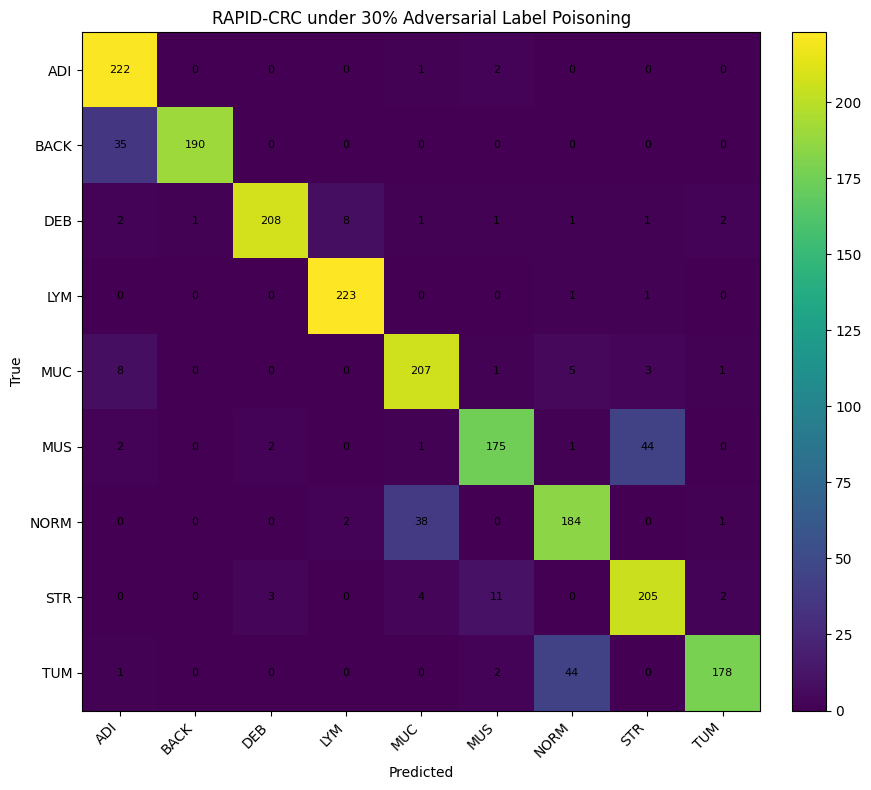

In [25]:
# ============================================================
# 13. CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

y_true = full_run["test"]["labels"]
y_pred = full_run["test"]["preds"]

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm)
ax.set_xticks(np.arange(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(np.arange(NUM_CLASSES), CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"RAPID-CRC under {int(round(ATTACK_RATE*100))}% Adversarial Label Poisoning")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Reliability mean | clean      : 0.6839789152145386
Reliability mean | adversarial: 0.38922879099845886


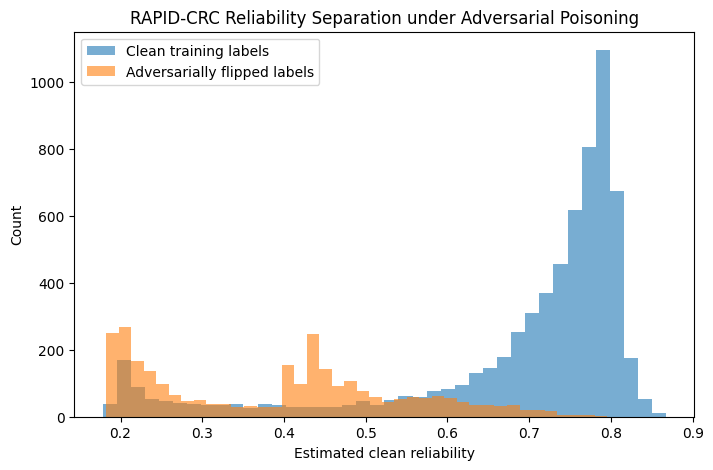


Lowest-reliability samples:


,sample_id,filepath,observed_poisoned_label,clean_label_eval_only,is_adversarially_flipped_eval_only,attack_target_eval_only,attack_score_eval_only,attack_gradient_conflict_eval_only,attack_target_plausibility_eval_only,reliability,loss_clean_signal,consistency_clean_signal,proto_clean_signal,grad_clean_signal,teacher_conf
5696,5696,/content/Dataset/STR/STR-SVAGDIYD.jpg,7,7,0,6,0.726093,0.884964,1.000000,0.178021,0.000335,0.877081,0.009949,0.0,0.233359
8159,8159,/content/Dataset/STR/STR-QGWKKAGQ.jpg,7,7,0,6,0.342638,0.729911,1.000000,0.178221,0.000335,0.889253,0.001012,0.0,0.258404
5230,5230,/content/Dataset/DEB/DEB-VWVALPVR.jpg,2,2,0,6,1.016667,0.852582,1.000000,0.181859,0.000335,0.898782,0.007939,0.0,0.205373
989,989,/content/Dataset/DEB/DEB-SYTRRFAH.jpg,2,2,0,4,0.988783,0.861739,1.000000,0.182457,0.000335,0.911278,0.000335,0.0,0.242306
5309,5309,/content/Dataset/DEB/DEB-RHNAKRTV.jpg,4,2,1,4,1.068214,0.838225,1.000000,0.182482,0.002230,0.852332,0.044939,0.0,0.282654
1411,1411,/content/Dataset/DEB/DEB-RNYCKDFI.jpg,2,2,0,7,1.009348,0.807958,0.994036,0.183349,0.000335,0.913449,0.002166,0.0,0.194164
8538,8538,/content/Dataset/STR/STR-NMFGTHPN.jpg,2,7,1,2,0.951617,0.805225,0.905467,0.184030,0.000335,0.919146,0.000335,0.0,0.214234
7511,7511,/content/Dataset/DEB/DEB-RPDEPPAG.jpg,2,2,0,5,0.722858,0.813492,1.000000,0.184216,0.000335,0.912900,0.006074,0.0,0.173761
1252,1252,/content/Dataset/STR/STR-WGWNCNAE.jpg,8,7,1,8,0.944085,0.802950,0.875897,0.185465,0.000335,0.914477,0.009809,0.0,0.183846
2547,2547,/content/Dataset/MUC/MUC-YATKIVDS.jpg,0,4,1,0,1.031185,0.799644,1.000000,0.185770,0.000335,0.921359,0.005522,0.0,0.277504



Saved diagnostics: /content/rapid_crc_adversarial_poison_diagnostics.csv


In [26]:
# ============================================================
# 15. ADVERSARIAL-POISON DETECTION DIAGNOSTICS
# ============================================================

rel = full_run["reliability"]

if rel is not None:
    gt_poison = train_df["is_flipped"].to_numpy(dtype=np.int64)
    clean_r = rel["reliability"][gt_poison == 0]
    poison_r = rel["reliability"][gt_poison == 1]

    print(
        "Reliability mean | clean      :",
        float(clean_r.mean()) if len(clean_r) else np.nan,
    )
    print(
        "Reliability mean | adversarial:",
        float(poison_r.mean()) if len(poison_r) else np.nan,
    )

    if len(clean_r) and len(poison_r):
        plt.figure(figsize=(8, 5))
        plt.hist(
            clean_r,
            bins=40,
            alpha=0.6,
            label="Clean training labels",
        )
        plt.hist(
            poison_r,
            bins=40,
            alpha=0.6,
            label="Adversarially flipped labels",
        )
        plt.xlabel("Estimated clean reliability")
        plt.ylabel("Count")
        plt.title(
            "RAPID-CRC Reliability Separation under Adversarial Poisoning"
        )
        plt.legend()
        plt.show()

    diag = pd.DataFrame({
        "sample_id": train_df["sample_id"].values,
        "filepath": train_df["filepath"].values,
        "observed_poisoned_label": train_df["label"].values,
        "clean_label_eval_only": train_df["label_clean"].values,
        "is_adversarially_flipped_eval_only": gt_poison,
        "attack_target_eval_only": train_df["attack_target"].values,
        "attack_score_eval_only": train_df["attack_score"].values,
        "attack_gradient_conflict_eval_only":
            train_df["attack_gradient_conflict"].values,
        "attack_target_plausibility_eval_only":
            train_df["attack_target_plausibility"].values,
        "reliability": rel["reliability"],
        "loss_clean_signal": rel["loss_clean"],
        "consistency_clean_signal": rel["consistency_clean"],
        "proto_clean_signal": rel["proto_clean"],
        "grad_clean_signal": rel["grad_clean"],
        "teacher_conf": rel["teacher_conf"],
    })

    diag_path = (
        WORK_DIR / "rapid_crc_adversarial_poison_diagnostics.csv"
    )
    diag.to_csv(diag_path, index=False)

    print("\nLowest-reliability samples:")
    display(diag.sort_values("reliability").head(20))

    print("\nSaved diagnostics:", diag_path)

## Optional ablation study

Set `RUN_ABLATIONS = True` to quantify which defense component matters under the **same fixed adversarially poisoned training set**.

Recommended variants:
- undefended CE baseline,
- RAPID-CRC without prototype reliability/loss,
- RAPID-CRC without gradient clustering,
- RAPID-CRC without EMA consistency,
- full RAPID-CRC.

For a paper, keep the same attack realization, split, seed, backbone, epoch budget, optimizer, and clean test set for every row.

In [27]:
# ============================================================
# 15. OPTIONAL ABLATION RUNNER
# ============================================================

RUN_ABLATIONS = False

if RUN_ABLATIONS:
    ablation_specs = {
        "A0_CE_baseline": None,
        "A1_no_prototype": MethodFlags(
            use_loss=True,
            use_consistency=True,
            use_prototype=False,
            use_gradient_cluster=True,
            use_pseudo_correction=True,
            use_prototype_loss=False,
        ),
        "A2_no_gradient": MethodFlags(
            use_loss=True,
            use_consistency=True,
            use_prototype=True,
            use_gradient_cluster=False,
            use_pseudo_correction=True,
            use_prototype_loss=True,
        ),
        "A3_no_consistency": MethodFlags(
            use_loss=True,
            use_consistency=False,
            use_prototype=True,
            use_gradient_cluster=True,
            use_pseudo_correction=True,
            use_prototype_loss=True,
        ),
        "A4_full": FULL_METHOD,
    }

    ablation_results = []

    for name, flags in ablation_specs.items():
        print("\n" + "=" * 80)
        print(name)

        if flags is None:
            # Pure CE baseline: same total number of epochs, no robust stage.
            run = fit_experiment(
                name=name,
                flags=MethodFlags(
                    use_loss=False,
                    use_consistency=False,
                    use_prototype=False,
                    use_gradient_cluster=False,
                    use_pseudo_correction=False,
                    use_prototype_loss=False,
                ),
                warmup_epochs=TOTAL_EPOCHS,
                robust_epochs=0,
                verbose=True,
            )
        else:
            run = fit_experiment(
                name=name,
                flags=flags,
                warmup_epochs=WARMUP_EPOCHS,
                robust_epochs=ROBUST_EPOCHS,
                verbose=True,
            )

        ablation_results.append(run["result"])

        del run
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    ablation_df = pd.DataFrame(ablation_results)
    ablation_df.to_csv(WORK_DIR / "rapid_crc_ablation_results.csv", index=False)
    display(ablation_df)
else:
    print("Ablations are OFF. Set RUN_ABLATIONS=True to run them.")

Ablations are OFF. Set RUN_ABLATIONS=True to run them.


In [28]:
# ============================================================
# 17. SAVE ATTACK / DEFENSE RESULTS
# ============================================================

full_run["history"].to_csv(
    WORK_DIR / "rapid_crc_adversarial_training_history.csv",
    index=False,
)

summary = {
    **full_run["result"],
    "seed": SEED,
    "attack_type": "offline_white_box_gradient_guided_label_flipping",
    "attack_rate_requested": ATTACK_RATE,
    "attack_rate_actual": float(train_df["is_flipped"].mean()),
    "attack_surrogate_epochs": ATTACK_SURROGATE_EPOCHS,
    "attack_grad_weight": ATTACK_GRAD_WEIGHT,
    "attack_plausibility_weight": ATTACK_PLAUS_WEIGHT,
    "attack_class_balanced": ATTACK_CLASS_BALANCED,
    "warmup_epochs": WARMUP_EPOCHS,
    "robust_epochs": ROBUST_EPOCHS,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "ema_decay": EMA_DECAY,
    "pretrained_loaded": bool(full_run["model"].pretrained_loaded),
}

if baseline_run is not None:
    summary.update({
        "undefended_test_accuracy":
            baseline_run["result"]["test_accuracy"],
        "undefended_test_f1_macro":
            baseline_run["result"]["test_f1_macro"],
        "defense_accuracy_recovery_pp": 100.0 * (
            full_run["result"]["test_accuracy"]
            - baseline_run["result"]["test_accuracy"]
        ),
        "defense_f1_recovery_pp": 100.0 * (
            full_run["result"]["test_f1_macro"]
            - baseline_run["result"]["test_f1_macro"]
        ),
    })

summary_path = WORK_DIR / "rapid_crc_adversarial_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print(WORK_DIR / "rapid_crc_adversarial_training_history.csv")
print(WORK_DIR / "rapid_crc_adversarial_poison_diagnostics.csv")
print(
    WORK_DIR
    / f"train_adversarial_poison_{int(round(ATTACK_RATE*100))}.csv"
)
print(WORK_DIR / "adversarial_transition_matrix.csv")
if baseline_run is not None:
    print(WORK_DIR / "adversarial_defense_comparison.csv")
print(summary_path)
print(full_run["checkpoint"])

Saved:
/content/rapid_crc_adversarial_training_history.csv
/content/rapid_crc_adversarial_poison_diagnostics.csv
/content/train_adversarial_poison_30.csv
/content/adversarial_transition_matrix.csv
/content/adversarial_defense_comparison.csv
/content/rapid_crc_adversarial_summary.json
/content/best_RAPID_CRC_ADV_30_DEFENDED.pth


## Methodological safeguards and interpretation

1. **Attack before victim training:** the surrogate is trained first, adversarial labels are generated, then RAPID-CRC's loaders are rebuilt.
2. **Adversarial rather than random:** the attacker uses surrogate gradients to choose both the attacked samples and malicious target labels.
3. **No defense leakage:** the victim dataset returns only image, observed label, sample ID, and path. It never returns clean labels or attack metadata.
4. **No test leakage:** the attack never reads the test set. Validation and test labels remain untouched and clean.
5. **Stable sample IDs:** reliability arrays are indexed by `sample_id`, avoiding shuffled-loader misalignment.
6. **Poison ground truth is evaluation-only:** it is used only after training for ROC-AUC, AP, precision, recall, F1, and reliability-separation diagnostics.
7. **Mitigation is compared against an undefended victim:** the optional CE control receives the identical poisoned labels. The defended-minus-undefended accuracy/F1 difference is the clearest evidence of mitigation.
8. **Attack claim:** this is a first-order, surrogate-based, white-box gradient-guided label-flipping attack. It is more targeted than random symmetric flipping, but it is not claimed to solve the exact bilevel optimal-poisoning problem.
9. **Publication next steps:** repeat multiple seeds and attack budgets, compare with random flipping and established defenses, run ablations, tune hyperparameters, and validate on a larger/external CRC dataset.